# Sampling Parameter Combinations — Accuracy Analysis

Evaluates whether **combining** the best individual sampling parameters beats any single-factor setting.

**8 combination configs** of Qwen3-4B across PrimeVul, JitVul, and CleanVul (C, C++, Java, Python):

| Config key | Parameters |
|---|---|
| `tp070-rp110` | top_p=0.70, repetition_penalty=1.10 |
| `rp110-pp150` | repetition_penalty=1.10, presence_penalty=1.50 |
| `tp070-pp150` | top_p=0.70, presence_penalty=1.50 |
| `t03-rp110-pp150` | temperature=0.3, top_p=0.70, repetition_penalty=1.10, presence_penalty=1.50 |
| `t12-rp110-pp150` | temperature=1.2, repetition_penalty=1.10, presence_penalty=1.50 |
| `t09-tp070-pp100-rp120` | temperature=0.9, top_p=0.70, presence_penalty=1.00, repetition_penalty=1.20 |
| `minp005-rp110` | min_p=0.05, repetition_penalty=1.10 |
| `minp005-rp110-pp150` | min_p=0.05, repetition_penalty=1.10, presence_penalty=1.50 |

Each config is run in both **thinking** and **non-thinking** modes.

Results are compared against:
- **Baseline** (`qwen3-4b-nt-base` / `qwen3-4b-base`): default temperature=0.6, no extra constraints
- **Best single-factor** configs from the prior sweep (loaded from `sampling_sweep_binary` results)

In [167]:
import json
import re
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 120

In [168]:
PROJECT_ROOT = Path('__file__').resolve().parent.parent
RESULTS_ROOT = PROJECT_ROOT / 'results'

# Combo suffix -> human-readable label + component params
COMBO_META = {
    # 'tp070-rp110':                  {'label': 'top_p=0.70\nrepeat=1.10',                                    'params': {'top_p': 0.70, 'repetition_penalty': 1.10}},
    # 'rp110-pp150':                  {'label': 'repeat=1.10\npresence=1.50',                                  'params': {'repetition_penalty': 1.10, 'presence_penalty': 1.50}},
    # 'tp070-pp150':                  {'label': 'top_p=0.70\npresence=1.50',                                   'params': {'top_p': 0.70, 'presence_penalty': 1.50}},
    't03-rp110-pp150':              {'label': 'temp=0.3\ntop_p=0.70\nrepeat=1.10\npresence=1.50',         'params': {'temperature': 0.3, 'top_p': 0.70, 'repetition_penalty': 1.10, 'presence_penalty': 1.50}},
    # 't12-rp110-pp150':              {'label': 'temp=1.2\nrepeat=1.10\npresence=1.50',                      'params': {'temperature': 1.2, 'repetition_penalty': 1.10, 'presence_penalty': 1.50}},
    't09-tp070-pp100-rp120':        {'label': 'temp=0.9\ntop_p=0.70\npresence=1.0\nrepeat=1.20 (Py)',    'params': {'temperature': 0.9, 'top_p': 0.70, 'presence_penalty': 1.0, 'repetition_penalty': 1.20}},
    # 'minp005-rp110':                {'label': 'min_p=0.05\nrepeat=1.10',                                    'params': {'min_p': 0.05, 'repetition_penalty': 1.10}},
    # 'minp005-rp110-pp150':          {'label': 'min_p=0.05\nrepeat=1.10\npresence=1.50',                   'params': {'min_p': 0.05, 'repetition_penalty': 1.10, 'presence_penalty': 1.50}},
    # 't03-minp010-rp120-pp150':      {'label': 'temp=0.3\nmin_p=0.10\nrepeat=1.20\npresence=1.50',        'params': {'temperature': 0.3, 'min_p': 0.10, 'repetition_penalty': 1.20, 'presence_penalty': 1.50}},
    # 't03-rp120':                    {'label': 'temp=0.3\nrepeat=1.20',                                      'params': {'temperature': 0.3, 'repetition_penalty': 1.20}},
    't03-tk080-rp130':              {'label': 'temp=0.3\ntop_k=80\nrepeat=1.30',                           'params': {'temperature': 0.3, 'top_k': 80, 'repetition_penalty': 1.30}},
    't03-tk080-rp130-minp010':      {'label': 'temp=0.3\ntop_k=80\nrepeat=1.30\nmin_p=0.10',             'params': {'temperature': 0.3, 'top_k': 80, 'repetition_penalty': 1.30, 'min_p': 0.10}},
    't03-tk020-rp130-minp005':      {'label': 'temp=0.3\ntop_k=20\nrepeat=1.30\nmin_p=0.05',             'params': {'temperature': 0.3, 'top_k': 20, 'repetition_penalty': 1.30, 'min_p': 0.05}},
    't09-rp120':                    {'label': 'temp=0.9\nrepeat=1.20',                                      'params': {'temperature': 0.9, 'repetition_penalty': 1.20}},
    # 't03-rp120-minp010':            {'label': 'temp=0.3\nrepeat=1.20\nmin_p=0.10',                        'params': {'temperature': 0.3, 'repetition_penalty': 1.20, 'min_p': 0.10}},
    't03-rp120-pp150':              {'label': 'temp=0.3\nrepeat=1.20\npresence=1.50',                      'params': {'temperature': 0.3, 'repetition_penalty': 1.20, 'presence_penalty': 1.50}},
}

# Best single-factor model names from prior sweep — used as reference lines
# Updated to reflect actual best values from sweep results
BEST_SINGLE_NT = {
    'top_p':             'qwen3-4b-nt-top-p-070',
    'top_k':             'qwen3-4b-nt-top-k-080',
    'repetition_penalty':'qwen3-4b-nt-repeat-110',
    'presence_penalty':  'qwen3-4b-nt-presence-150',
    'min_p':             'qwen3-4b-nt-min-p-005',
    'temperature':       'qwen3-4b-nt-temp-03',
}
BEST_SINGLE_T = {
    'top_p':             'qwen3-4b-top-p-070',
    'top_k':             'qwen3-4b-top-k-080',
    'repetition_penalty':'qwen3-4b-repeat-110',
    'presence_penalty':  'qwen3-4b-presence-150',
    'min_p':             'qwen3-4b-min-p-005',
    'temperature':       'qwen3-4b-temp-03',
}

DATASET_DISPLAY = {
    # 'castle':          'CASTLE',
    'jitvul':          'JitVul',
    'primevul':        'PrimeVul',
    'cleanvul_c': 'CleanVul (C)',
    'cleanvul_cpp': 'CleanVul (C++)',
    'cleanvul_python': 'CleanVul (Python)',
    'cleanvul_java': 'CleanVul (Java)',
}

DATASETS_ORDERED    = [
    # 'castle',
    'jitvul', 'primevul', 'cleanvul_c', 'cleanvul_cpp', 'cleanvul_python', 'cleanvul_java'
    ]
PARAM_TYPES_ORDERED = ['temperature', 'min_p', 'top_k', 'top_p', 'presence_penalty', 'repetition_penalty']

DATASET_COLORS = {
    # 'castle':          '#4e79a7',
    'jitvul':          '#59a14f',
    'primevul':        '#115759',
    'cleanvul_c':      '#e15759',
    'cleanvul_cpp':    '#f9a14f',
    'cleanvul_python': '#76b7b2',
    'cleanvul_java':   '#edc949',
}


In [169]:
## Data loading helpers

def _dataset_key(path: str) -> str:
    if 'castle' in path:
        return 'castle'
    if 'jitvul' in path:
        return 'jitvul'
    if 'primevul' in path:
        return 'primevul'
    if "cleanvul" in path:
        if "_py" in path:
            return 'cleanvul_python'
        if "_java" in path:
            return 'cleanvul_java'
        if "_cpp" in path:
            return 'cleanvul_cpp'
        if "_c" in path:
            return 'cleanvul_c'
    if 'cvefixes' in path:
        return 'cvefixes_python' if 'python' in path else 'cvefixes_c'
    raise ValueError(f'Unknown dataset path: {path}')


def _combo_suffix(model_name: str) -> str | None:
    """Extract the combo suffix from a model name like qwen3-4b[-nt]-combo-<suffix>."""
    m = re.match(r'^qwen3-4b-(?:nt-)?combo-(.+)$', model_name)
    return m.group(1) if m else None


def _finalize_results(rows: dict[tuple[str, str], dict]) -> pd.DataFrame:
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(list(rows.values()))
    total = df['TP'] + df['TN'] + df['FP'] + df['FN']
    df['accuracy']   = (df['TP'] + df['TN']) / total
    df['precision']  = df['TP'] / (df['TP'] + df['FP']).replace(0, np.nan)
    df['recall']     = df['TP'] / (df['TP'] + df['FN']).replace(0, np.nan)
    df['FNR']        = df['FN'] / (df['TP'] + df['FN']).replace(0, np.nan)
    df['FPR']        = df['FP'] / (df['FP'] + df['TN']).replace(0, np.nan)
    df['specificity']= df['TN'] / (df['TN'] + df['FP']).replace(0, np.nan)
    df['f1']         = 2 * df['TP'] / (2 * df['TP'] + df['FP'] + df['FN']).replace(0, np.nan)
    df['balanced_accuracy'] = (df['recall'] + df['specificity']) / 2
    mcc_denom = np.sqrt(
        (df['TP'] + df['FP']) * (df['TP'] + df['FN']) *
        (df['TN'] + df['FP']) * (df['TN'] + df['FN'])
    ).replace(0, np.nan)
    df['MCC']        = (df['TP'] * df['TN'] - df['FP'] * df['FN']) / mcc_denom
    df['youden_j']   = df['recall'] + df['specificity'] - 1
    df['tokens_avg'] = df['tokens_total'] / total
    df['time_avg']   = df['time_total'] / total
    df['total_samples'] = total
    df['dataset_label'] = df['dataset'].map(DATASET_DISPLAY)
    return df


def load_results(plan_pattern: str, model_prefix: str, thinking: bool) -> pd.DataFrame:
    """
    Load all metrics_summary_*.json files matching a plan pattern.
    Aggregates multiple runs for the same config by summing confusion matrices.
    """
    rows = {}
    for path in RESULTS_ROOT.glob(f'*_experiments/{plan_pattern}/**/{model_prefix}*/step_by_step/metrics_summary_*.json'):
        data = json.loads(path.read_text())
        info    = data['benchmark_info']
        metrics = data['metrics']
        model_name = info['model']['model_name']
        suffix = _combo_suffix(model_name)
        if suffix is None or suffix not in COMBO_META:
            continue
        ds = _dataset_key(str(path))
        key = (model_name, ds)

        cm = metrics['details']['confusion_matrix']
        stats = info['stats']

        if key not in rows:
            rows[key] = {
                'model_name': model_name,
                'combo_suffix': suffix,
                'combo_label': COMBO_META.get(suffix, {}).get('label', suffix),
                'dataset': ds,
                'is_thinking': thinking,
                'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0,
                'tokens_total': 0, 'time_total': 0, 'n_runs': 0,
            }
        rows[key]['TP'] += cm['true_positives']
        rows[key]['TN'] += cm['true_negatives']
        rows[key]['FP'] += cm['false_positives']
        rows[key]['FN'] += cm['false_negatives']
        rows[key]['tokens_total'] += stats['tokens_used_avg'] * stats['total_samples']
        rows[key]['time_total']   += stats['avg_time_per_sample'] * stats['total_samples']
        rows[key]['n_runs'] += 1

    return _finalize_results(rows)


def load_reference_results(
    plan_patterns: list[str],
    model_names: set[str],
    thinking: bool,
    combo_suffix_map: dict[str, str] | None = None,
    combo_label_map: dict[str, str] | None = None,
) -> pd.DataFrame:
    """
    Load explicit reference models from one or more prior sweep plans.
    This is used for baseline rows that were not run inside the combinations plans.
    """
    rows = {}
    for plan_pattern in plan_patterns:
        for path in RESULTS_ROOT.glob(f'*_experiments/{plan_pattern}/**/step_by_step/metrics_summary_*.json'):
            data = json.loads(path.read_text())
            info = data['benchmark_info']
            model_name = info['model']['model_name']
            if model_name not in model_names:
                continue

            ds = _dataset_key(str(path))
            key = (model_name, ds)
            cm = data['metrics']['details']['confusion_matrix']
            stats = info['stats']

            if key not in rows:
                rows[key] = {
                    'model_name': model_name,
                    'combo_suffix': combo_suffix_map.get(model_name, model_name) if combo_suffix_map else model_name,
                    'combo_label': combo_label_map.get(model_name, model_name) if combo_label_map else model_name,
                    'dataset': ds,
                    'is_thinking': thinking,
                    'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0,
                    'tokens_total': 0, 'time_total': 0, 'n_runs': 0,
                }
            rows[key]['TP'] += cm['true_positives']
            rows[key]['TN'] += cm['true_negatives']
            rows[key]['FP'] += cm['false_positives']
            rows[key]['FN'] += cm['false_negatives']
            rows[key]['tokens_total'] += stats['tokens_used_avg'] * stats['total_samples']
            rows[key]['time_total']   += stats['avg_time_per_sample'] * stats['total_samples']
            rows[key]['n_runs'] += 1

    return _finalize_results(rows)


def load_single_factor_baselines(plan_patterns: list[str]) -> dict:
    """
    Returns {(model_name, dataset_key): accuracy} for the best single-factor configs.
    Used to draw reference lines on plots.
    """
    all_models = set(BEST_SINGLE_NT.values()) | set(BEST_SINGLE_T.values()) | {'qwen3-4b-nt-base', 'qwen3-4b-base'}
    result = {}
    for plan_pattern in plan_patterns:
        for path in RESULTS_ROOT.glob(f'*_experiments/{plan_pattern}/**/step_by_step/metrics_summary_*.json'):
            data = json.loads(path.read_text())
            model_name = data['benchmark_info']['model']['model_name']
            if model_name not in all_models:
                continue
            ds = _dataset_key(str(path))
            key = (model_name, ds)
            cm = data['metrics']['details']['confusion_matrix']
            if key not in result:
                result[key] = {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
            result[key]['TP'] += cm['true_positives']
            result[key]['TN'] += cm['true_negatives']
            result[key]['FP'] += cm['false_positives']
            result[key]['FN'] += cm['false_negatives']
    return {
        k: (v['TP'] + v['TN']) / (v['TP'] + v['TN'] + v['FP'] + v['FN'])
        for k, v in result.items()
    }


# Load combination results
df_nt = load_results('sampling_sweep_combinations',          'qwen3-4b-nt-combo', thinking=False)
df_t  = load_results('sampling_sweep_combinations_thinking', 'qwen3-4b-combo',    thinking=True)

# Baselines were run in the earlier binary sweeps, not in the combination plans.
baseline_nt = load_reference_results(
    ['sampling_sweep_binary', 'sampling_sweep_combinations'],
    {'qwen3-4b-nt-base'},
    thinking=False,
    combo_suffix_map={'qwen3-4b-nt-base': 'baseline'},
    combo_label_map={'qwen3-4b-nt-base': 'Baseline'},
)
baseline_t = load_reference_results(
    ['sampling_sweep_binary_thinking', 'sampling_sweep_combinations_thinking'],
    {'qwen3-4b-base'},
    thinking=True,
    combo_suffix_map={'qwen3-4b-base': 'baseline'},
    combo_label_map={'qwen3-4b-base': 'Baseline'},
)

df_nt = pd.concat([df_nt, baseline_nt], ignore_index=True)
df_t  = pd.concat([df_t, baseline_t], ignore_index=True)
df    = pd.concat([df_t, df_nt], ignore_index=True)

# Load single-factor reference baselines from the earlier binary sweeps.
sf_nt = load_single_factor_baselines(['sampling_sweep_binary', 'sampling_sweep_combinations'])
sf_t  = load_single_factor_baselines(['sampling_sweep_binary_thinking', 'sampling_sweep_combinations_thinking'])

print(f'Loaded {len(df_t)} thinking rows, {len(df_nt)} non-thinking rows')
print(f'Baseline rows: {len(baseline_t)} thinking, {len(baseline_nt)} non-thinking')
print(f'Single-factor references: {len(sf_nt)} NT, {len(sf_t)} T')
df[['combo_label','dataset_label','accuracy','recall','specificity','FNR','MCC','is_thinking']]
baseline_nt

Loaded 56 thinking rows, 56 non-thinking rows
Baseline rows: 7 thinking, 7 non-thinking
Single-factor references: 49 NT, 49 T


,model_name,combo_suffix,combo_label,dataset,is_thinking,TP,TN,FP,FN,tokens_total,...,FPR,specificity,f1,balanced_accuracy,MCC,youden_j,tokens_avg,time_avg,total_samples,dataset_label
0,qwen3-4b-nt-base,baseline,Baseline,jitvul,False,92,21,71,16,380616.0,...,0.771739,0.228261,0.678967,0.540056,0.102828,0.080113,1903.08000,0.378963,200,JitVul
1,qwen3-4b-nt-base,baseline,Baseline,primevul,False,152,70,140,38,573866.0,...,0.666667,0.333333,0.630705,0.566667,0.149976,0.133333,1434.66500,0.317007,400,PrimeVul
2,qwen3-4b-nt-base,baseline,Baseline,castle,False,85,41,39,35,175077.0,...,0.487500,0.512500,0.696721,0.610417,0.222886,0.220833,875.38500,0.206473,200,NaN
3,qwen3-4b-nt-base,baseline,Baseline,cleanvul_cpp,False,40,6,47,13,164984.0,...,0.886792,0.113208,0.571429,0.433962,-0.172172,-0.132075,1556.45283,0.320999,106,CleanVul (C++)
4,qwen3-4b-nt-base,baseline,Baseline,cleanvul_python,False,94,8,91,7,278421.0,...,0.919192,0.080808,0.657343,0.505751,0.021832,0.011501,1392.10500,0.290009,200,CleanVul (Python)
5,qwen3-4b-nt-base,baseline,Baseline,cleanvul_java,False,96,19,69,16,237641.0,...,0.784091,0.215909,0.693141,0.536526,0.095435,0.073052,1188.20500,0.276359,200,CleanVul (Java)
6,qwen3-4b-nt-base,baseline,Baseline,cleanvul_c,False,84,20,75,21,390949.0,...,0.789474,0.210526,0.636364,0.505263,0.013021,0.010526,1954.74500,0.381816,200,CleanVul (C)


## Accuracy Overview — All Combos × Datasets

Non-Thinking baseline accuracies: [0.565, 0.555, 0.52, 0.4339622641509434, 0.51, 0.575]


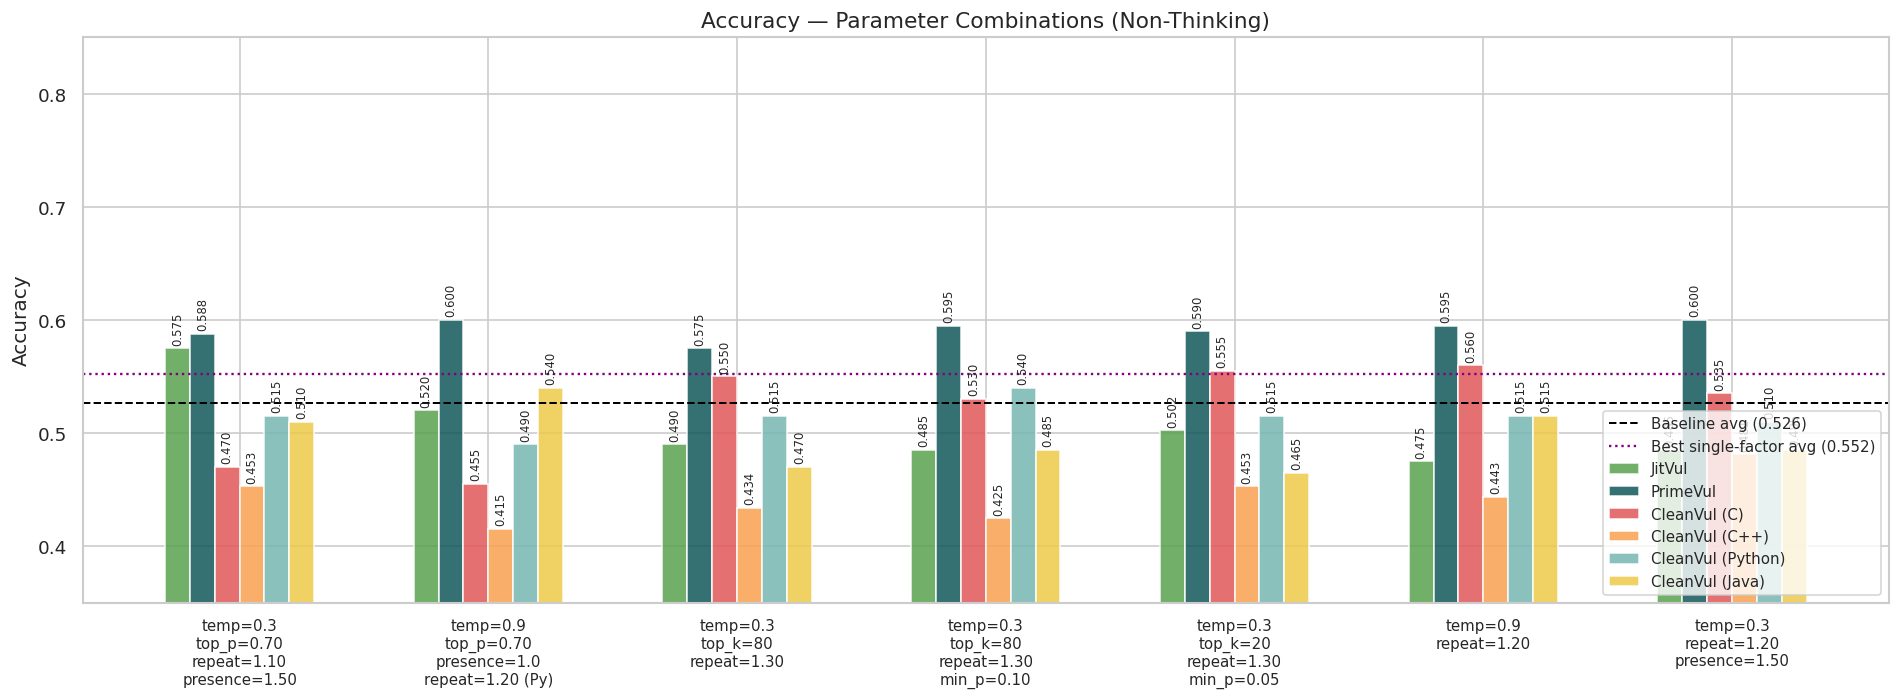

Thinking baseline accuracies: [0.54, 0.515, 0.52, 0.4528301886792453, 0.59, 0.52]


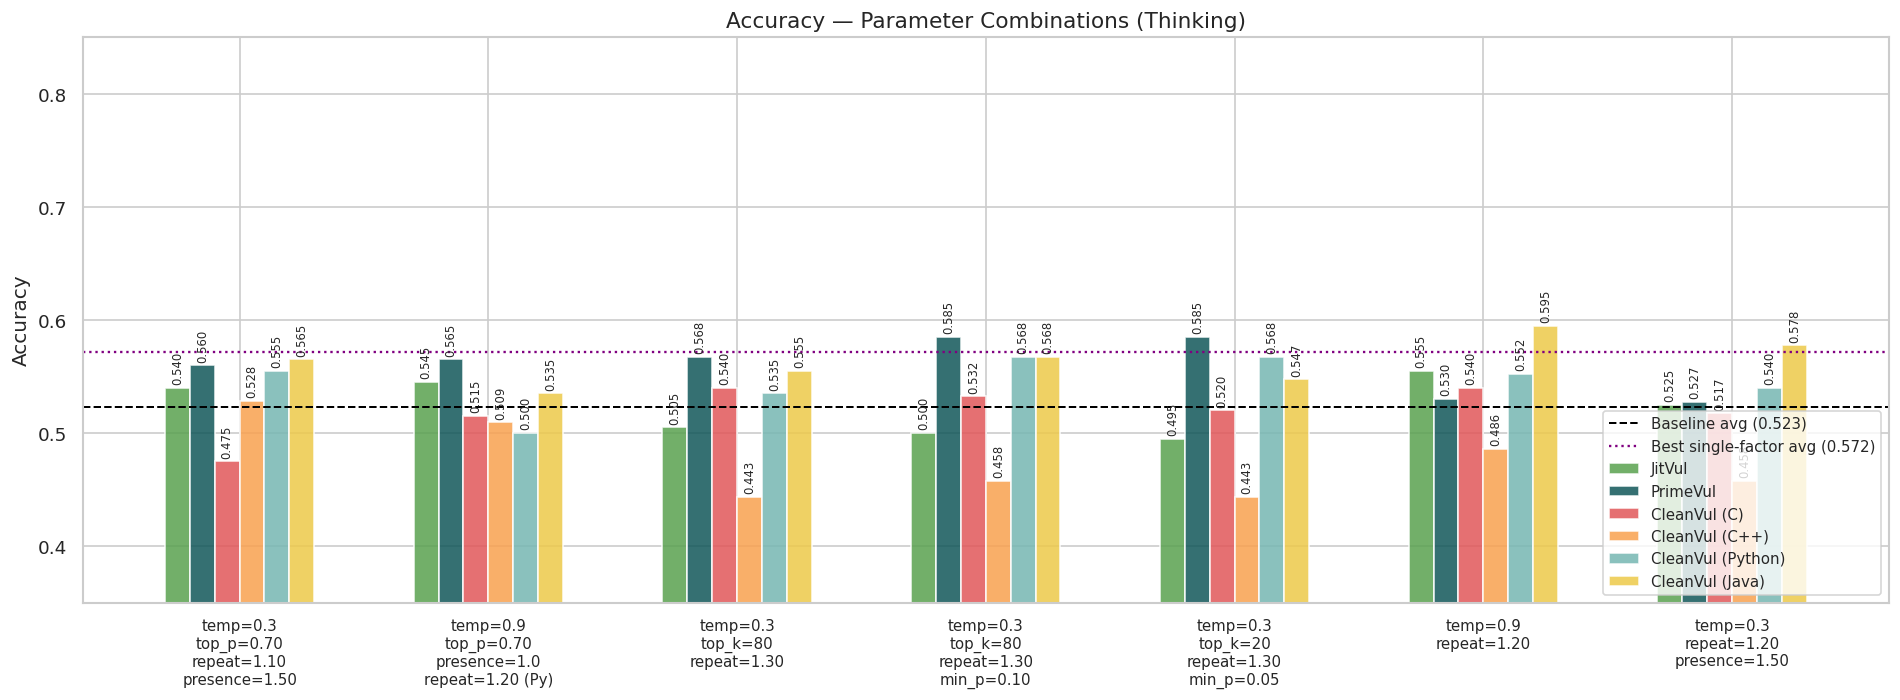

In [170]:
## Grouped bar chart: accuracy per combo config, grouped by dataset
## Reference lines: baseline (nt-base / base) and best single-factor

def _ref_acc(sf: dict, model: str, ds: str) -> float:
    v = sf.get((model, ds))
    return float(v) if v is not None else np.nan


for thinking, df_mode, sf, baseline_model, title_suffix in [
    (False, df_nt, sf_nt, 'qwen3-4b-nt-base',  'Non-Thinking'),
    (True,  df_t,  sf_t,  'qwen3-4b-base',      'Thinking'),
]:
    if df_mode.empty:
        print(f'No data for {title_suffix}')
        continue

    combos   = list(COMBO_META.keys())
    n_combos = len(combos)
    n_ds     = len(DATASETS_ORDERED)
    bar_w    = 0.1
    x        = np.arange(n_combos)

    fig, ax = plt.subplots(figsize=(16, 6))

    for i, ds in enumerate(DATASETS_ORDERED):
        accs = []
        for combo in combos:
            row = df_mode[(df_mode['combo_suffix'] == combo) & (df_mode['dataset'] == ds)]
            accs.append(float(row['accuracy'].iloc[0]) if not row.empty else np.nan)
        bars = ax.bar(x + i * bar_w, accs, bar_w, label=DATASET_DISPLAY[ds],
                      color=DATASET_COLORS[ds], alpha=0.85)
        for bar, acc in zip(bars, accs):
            if not np.isnan(acc):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                        f'{acc:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

    # Reference lines: baseline and best single-factor (average across datasets)
    bl_accs = np.array([_ref_acc(sf, baseline_model, ds) for ds in DATASETS_ORDERED], dtype=float)
    print(f'{title_suffix} baseline accuracies: {bl_accs.tolist()}')
    if np.isfinite(bl_accs).any():
        bl_mean = np.nanmean(bl_accs)
        ax.axhline(bl_mean, color='black', linestyle='--', linewidth=1.2, label=f'Baseline avg ({bl_mean:.3f})')

    # Best single-factor per dataset as horizontal span reference
    best_sf_accs = []
    for ds in DATASETS_ORDERED:
        best_sf = max(
            _ref_acc(sf, m, ds) for m in (BEST_SINGLE_NT if not thinking else BEST_SINGLE_T).values()
        )
        best_sf_accs.append(best_sf)
    best_sf_accs = np.array(best_sf_accs, dtype=float)
    if np.isfinite(best_sf_accs).any():
        best_sf_mean = np.nanmean(best_sf_accs)
        ax.axhline(best_sf_mean, color='purple', linestyle=':', linewidth=1.4,
                   label=f'Best single-factor avg ({best_sf_mean:.3f})')

    combo_labels = [COMBO_META[c]['label'] for c in combos]
    ax.set_xticks(x + bar_w * (n_ds - 1) / 2)
    ax.set_xticklabels(combo_labels, fontsize=9)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy — Parameter Combinations ({title_suffix})', fontsize=13)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0.35, 0.85)
    plt.tight_layout()
    plt.show()

## Delta vs Baseline — All Combos × Datasets

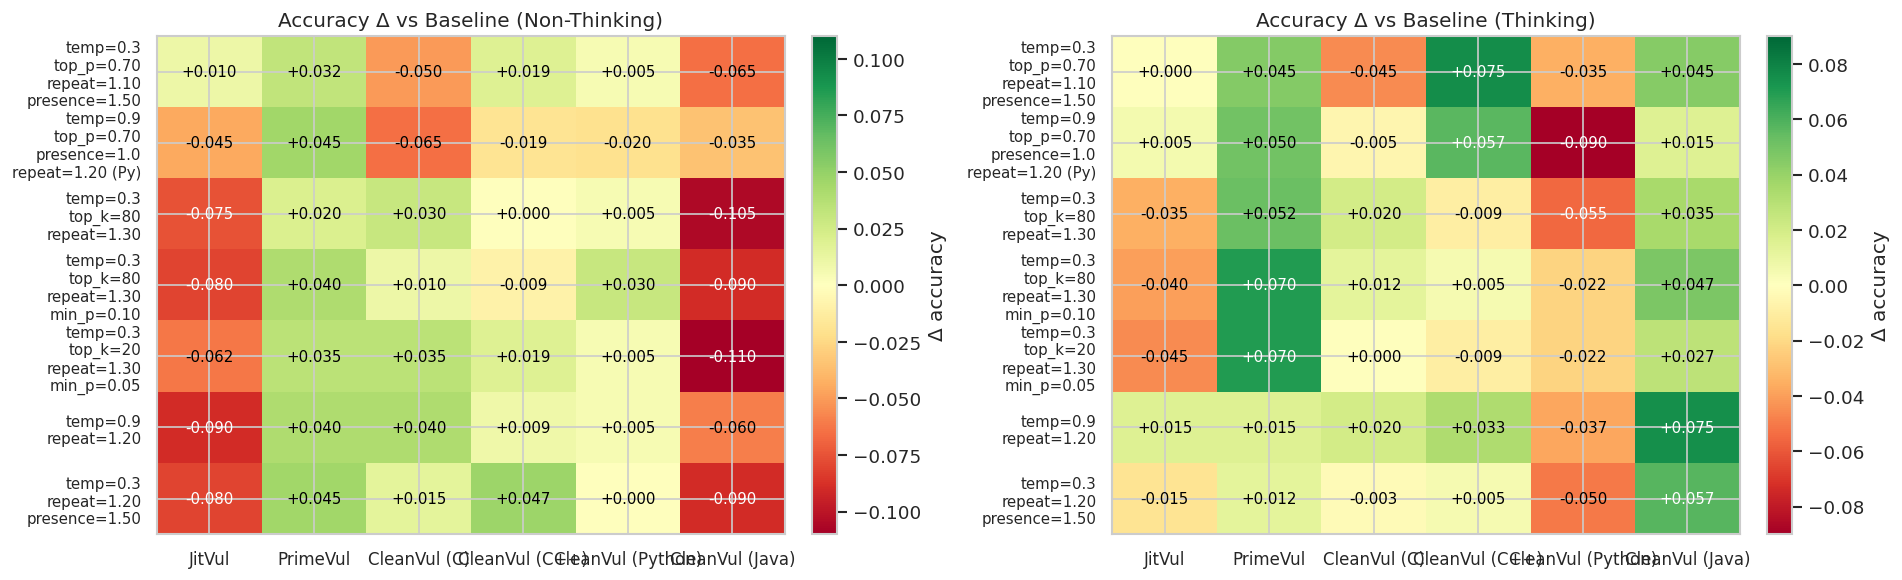

In [177]:
## Heatmap: accuracy delta of each combo over its respective baseline (green = improvement)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df_mode, sf, baseline_model, title_suffix) in zip(axes, [
    (df_nt, sf_nt, 'qwen3-4b-nt-base',  'Non-Thinking'),
    (df_t,  sf_t,  'qwen3-4b-base',      'Thinking'),
]):
    if df_mode.empty:
        ax.set_title(f'No data ({title_suffix})')
        continue

    # Build delta matrix: rows=combos, cols=datasets
    matrix = []
    for combo in COMBO_META:
        row = []
        for ds in DATASETS_ORDERED:
            r = df_mode[(df_mode['combo_suffix'] == combo) & (df_mode['dataset'] == ds)]
            combo_acc = float(r['accuracy'].iloc[0]) if not r.empty else np.nan
            bl_acc    = _ref_acc(sf, baseline_model, ds)
            row.append(combo_acc - bl_acc if (bl_acc is not None and not np.isnan(combo_acc)) else np.nan)
        matrix.append(row)

    mat  = np.array(matrix, dtype=float)
    vmax = max(abs(np.nanmax(mat)), abs(np.nanmin(mat)), 0.02)
    im   = ax.imshow(mat, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Δ accuracy')

    for i in range(len(COMBO_META)):
        for j in range(len(DATASETS_ORDERED)):
            val = mat[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9,
                        color='black' if abs(val) < vmax * 0.6 else 'white')

    ax.set_xticks(range(len(DATASETS_ORDERED)))
    ax.set_xticklabels([DATASET_DISPLAY[d] for d in DATASETS_ORDERED], fontsize=10)
    ax.set_yticks(range(len(COMBO_META)))
    ax.set_yticklabels([COMBO_META[c]['label'] for c in COMBO_META], fontsize=9)
    ax.set_title(f'Accuracy Δ vs Baseline ({title_suffix})', fontsize=12)

plt.tight_layout()
plt.show()

## Delta vs Best Single-Factor

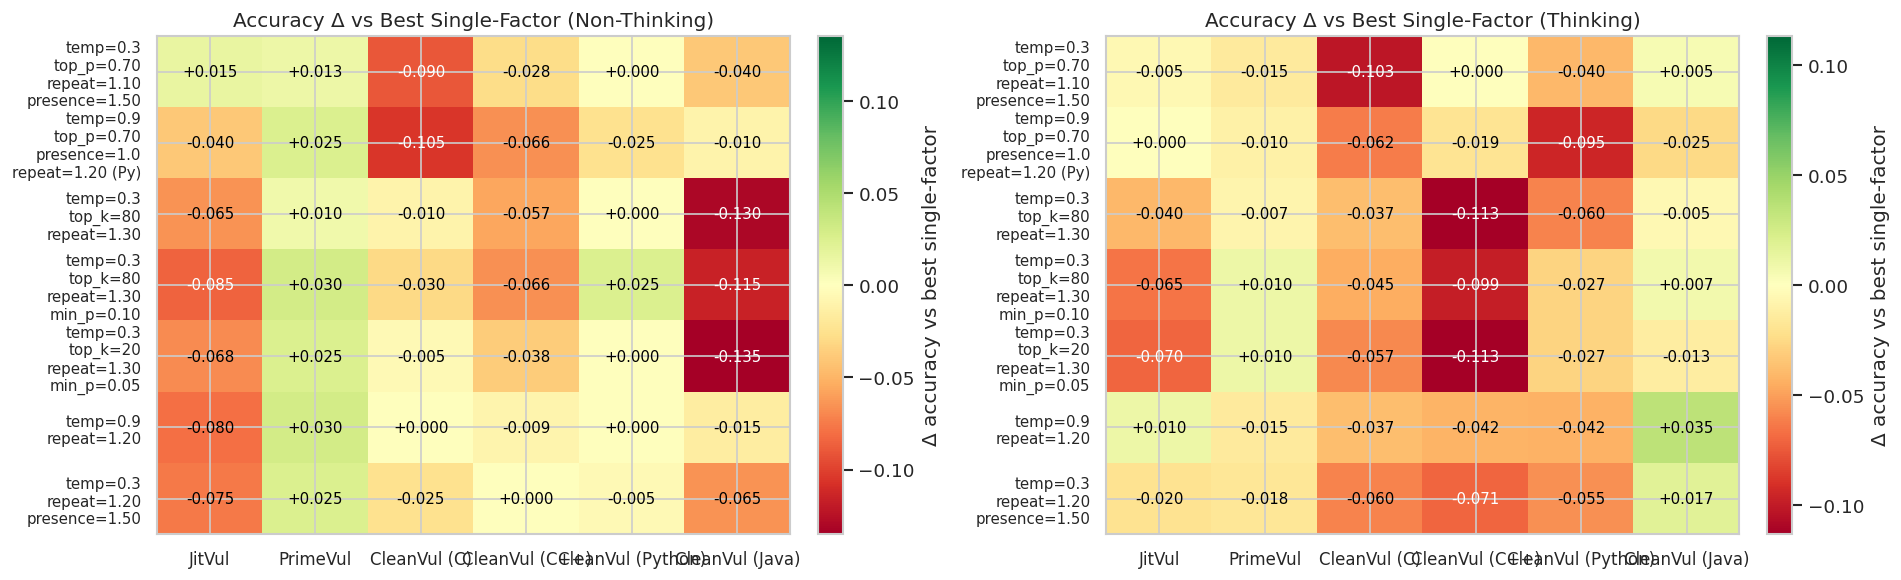

In [172]:
## Heatmap: combo accuracy minus best single-factor accuracy (per dataset)
## Green = combination actually beats all individual settings

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df_mode, sf, thinking, title_suffix) in zip(axes, [
    (df_nt, sf_nt, False, 'Non-Thinking'),
    (df_t,  sf_t,  True,  'Thinking'),
]):
    if df_mode.empty:
        ax.set_title(f'No data ({title_suffix})')
        continue

    best_map = BEST_SINGLE_NT if not thinking else BEST_SINGLE_T

    matrix = []
    for combo in COMBO_META:
        row = []
        for ds in DATASETS_ORDERED:
            r = df_mode[(df_mode['combo_suffix'] == combo) & (df_mode['dataset'] == ds)]
            combo_acc = float(r['accuracy'].iloc[0]) if not r.empty else np.nan
            # Best single-factor that is relevant to this combo's params
            combo_params = COMBO_META[combo]['params']
            best_sf_acc  = max(
                (_ref_acc(sf, best_map[p], ds) or 0)
                for p in combo_params if p in best_map
            ) if combo_params else np.nan
            row.append(combo_acc - best_sf_acc if (not np.isnan(combo_acc) and best_sf_acc) else np.nan)
        matrix.append(row)

    mat  = np.array(matrix, dtype=float)
    vmax = max(abs(np.nanmax(mat)), abs(np.nanmin(mat)), 0.02)
    im   = ax.imshow(mat, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Δ accuracy vs best single-factor')

    for i in range(len(COMBO_META)):
        for j in range(len(DATASETS_ORDERED)):
            val = mat[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9,
                        color='black' if abs(val) < vmax * 0.6 else 'white')

    ax.set_xticks(range(len(DATASETS_ORDERED)))
    ax.set_xticklabels([DATASET_DISPLAY[d] for d in DATASETS_ORDERED], fontsize=10)
    ax.set_yticks(range(len(COMBO_META)))
    ax.set_yticklabels([COMBO_META[c]['label'] for c in COMBO_META], fontsize=9)
    ax.set_title(f'Accuracy Δ vs Best Single-Factor ({title_suffix})', fontsize=12)

plt.tight_layout()
plt.show()

## FNR Comparison — Combinations vs Baseline

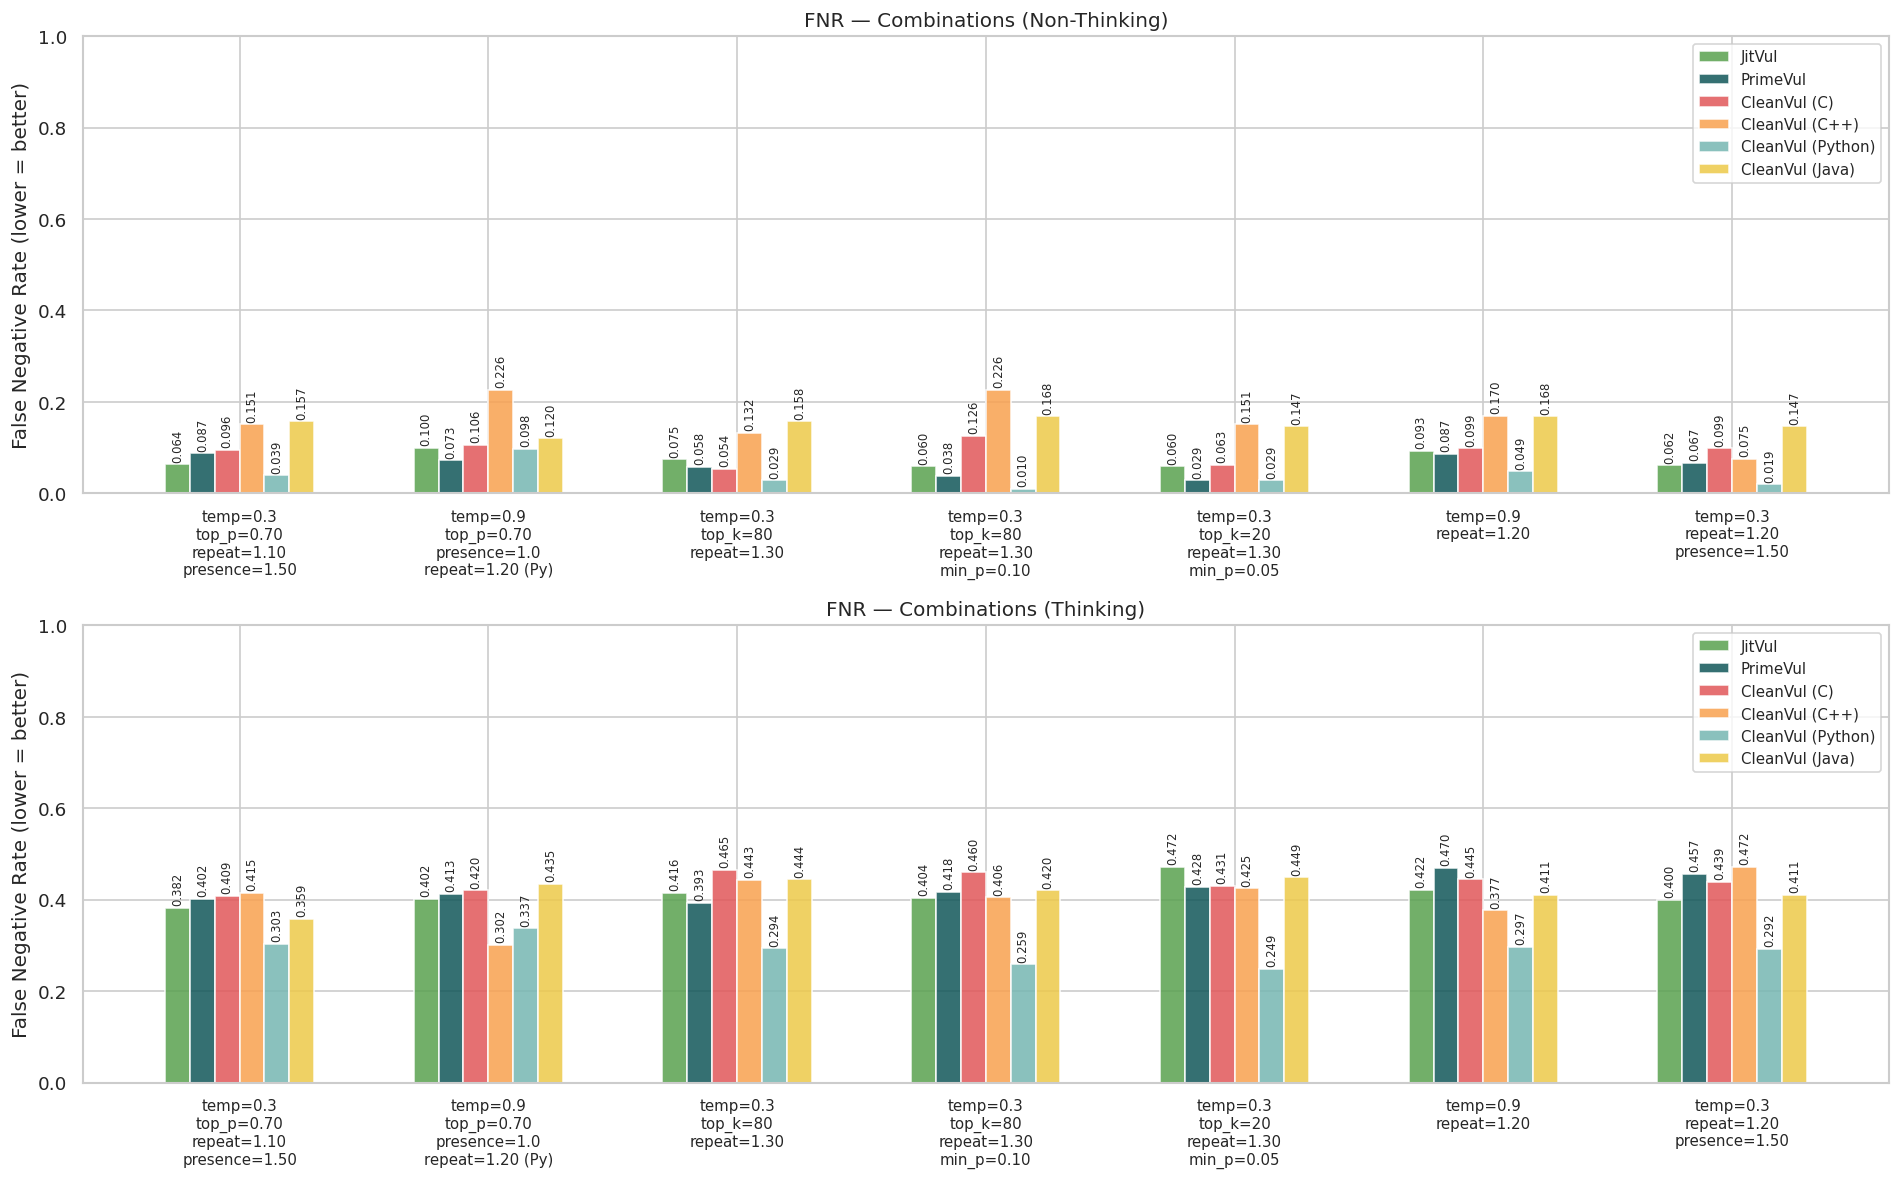

In [173]:
## FNR per combo x dataset — lower is better (fewer missed vulnerabilities)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, (df_mode, sf, baseline_model, title_suffix) in zip(axes, [
    (df_nt, sf_nt, 'qwen3-4b-nt-base',  'Non-Thinking'),
    (df_t,  sf_t,  'qwen3-4b-base',      'Thinking'),
]):
    if df_mode.empty:
        ax.set_title(f'No data ({title_suffix})')
        continue

    combos = list(COMBO_META.keys())
    x = np.arange(len(combos))
    bar_w = 0.1

    for i, ds in enumerate(DATASETS_ORDERED):
        fnrs = []
        for combo in combos:
            r = df_mode[(df_mode['combo_suffix'] == combo) & (df_mode['dataset'] == ds)]
            fnrs.append(float(r['FNR'].iloc[0]) if not r.empty else np.nan)
        ax.bar(x + i * bar_w, fnrs, bar_w, label=DATASET_DISPLAY[ds],
               color=DATASET_COLORS[ds], alpha=0.85)
        for xi, fnr in zip(x + i * bar_w, fnrs):
            if not np.isnan(fnr):
                ax.text(xi, fnr + 0.005, f'{fnr:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_xticks(x + bar_w * (len(DATASETS_ORDERED) - 1) / 2)
    ax.set_xticklabels([COMBO_META[c]['label'] for c in combos], fontsize=9)
    ax.set_ylabel('False Negative Rate (lower = better)')
    ax.set_title(f'FNR — Combinations ({title_suffix})', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

## Thinking vs Non-Thinking — Combo-by-Combo

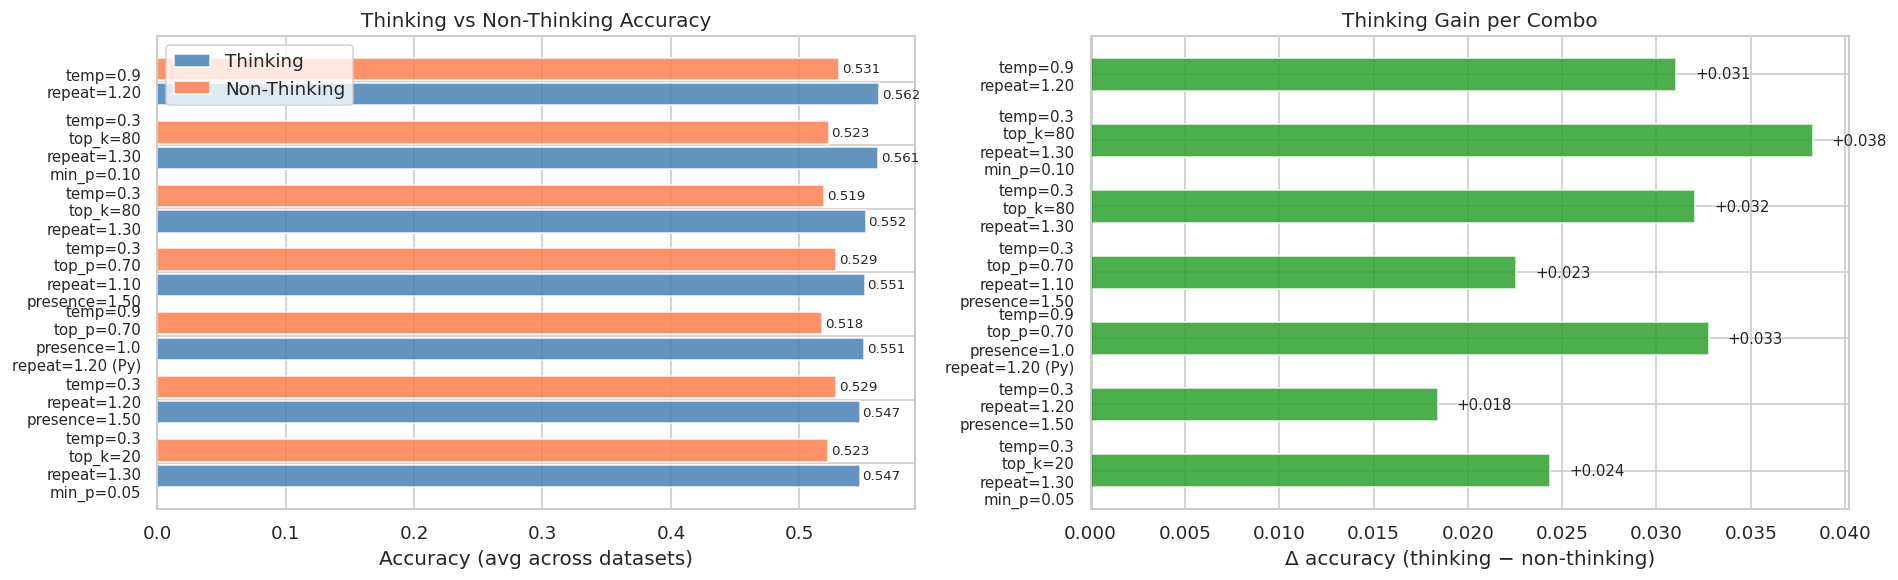

,combo_suffix,thinking,non_thinking,delta
0,t03-tk020-rp130-minp005,0.5469,0.5225,0.0244
1,t03-rp120-pp150,0.5471,0.5287,0.0184
2,t09-tp070-pp100-rp120,0.5506,0.5179,0.0328
3,t03-rp110-pp150,0.5512,0.5286,0.0226
4,t03-tk080-rp130,0.5516,0.5195,0.0321
5,t03-tk080-rp130-minp010,0.5614,0.5231,0.0383
6,t09-rp120,0.5623,0.5312,0.0311


In [174]:
## Side-by-side: thinking vs non-thinking accuracy for each combo (avg across datasets)

if df_t.empty or df_nt.empty:
    print('Need both thinking and non-thinking results for comparison')
else:
    avg_t  = df_t.groupby('combo_suffix')['accuracy'].mean().rename('thinking')
    avg_nt = df_nt.groupby('combo_suffix')['accuracy'].mean().rename('non_thinking')
    cmp    = pd.concat([avg_t, avg_nt], axis=1).reindex(list(COMBO_META.keys()))
    cmp['delta'] = cmp['thinking'] - cmp['non_thinking']
    cmp['label'] = [COMBO_META[c]['label'] for c in cmp.index]
    cmp = cmp.sort_values('thinking', ascending=True).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: absolute accuracy
    ax = axes[0]
    y  = np.arange(len(cmp))
    ax.barh(y - 0.2, cmp['thinking'],     0.35, label='Thinking',     color='steelblue', alpha=0.85)
    ax.barh(y + 0.2, cmp['non_thinking'], 0.35, label='Non-Thinking', color='coral',     alpha=0.85)
    for yi, row in zip(y, cmp.itertuples()):
        ax.text(row.thinking     + 0.002, yi - 0.2, f'{row.thinking:.3f}',     va='center', fontsize=8)
        ax.text(row.non_thinking + 0.002, yi + 0.2, f'{row.non_thinking:.3f}', va='center', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(cmp['label'], fontsize=9)
    ax.set_xlabel('Accuracy (avg across datasets)')
    ax.set_title('Thinking vs Non-Thinking Accuracy')
    ax.legend()

    # Right: delta (thinking - non-thinking)
    ax = axes[1]
    colors = ['#2ca02c' if d >= 0 else '#d62728' for d in cmp['delta']]
    ax.barh(y, cmp['delta'], 0.5, color=colors, alpha=0.85)
    for yi, d in zip(y, cmp['delta']):
        ax.text(d + 0.001 if d >= 0 else d - 0.001, yi,
                f'{d:+.3f}', va='center', ha='left' if d >= 0 else 'right', fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(cmp['label'], fontsize=9)
    ax.set_xlabel('Δ accuracy (thinking − non-thinking)')
    ax.set_title('Thinking Gain per Combo')

    plt.tight_layout()
    plt.show()
    display(cmp[['combo_suffix', 'thinking', 'non_thinking', 'delta']].round(4))

## Radar / Spider Chart — Combos across Metrics

/tmp/ipykernel_838864/761996503.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(combos))


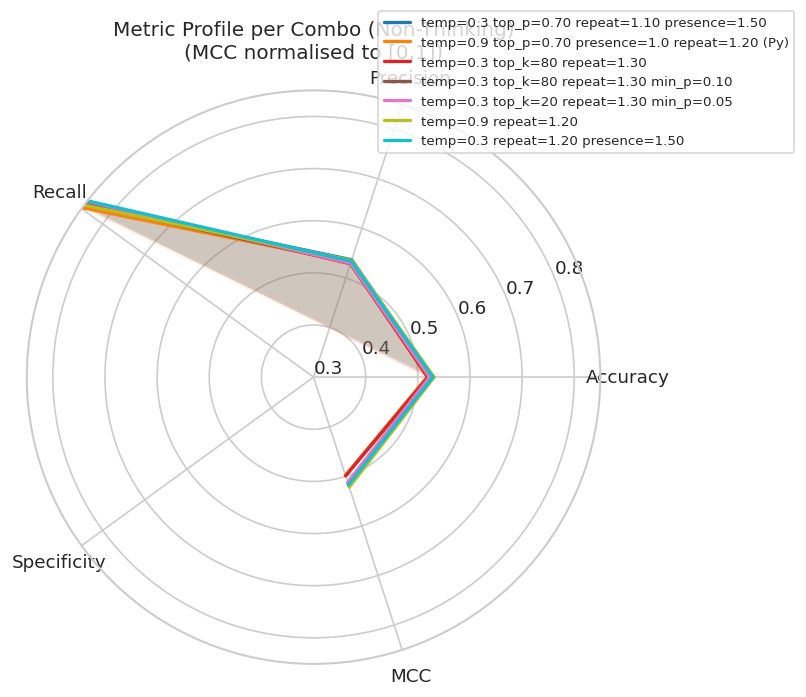

/tmp/ipykernel_838864/761996503.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(combos))


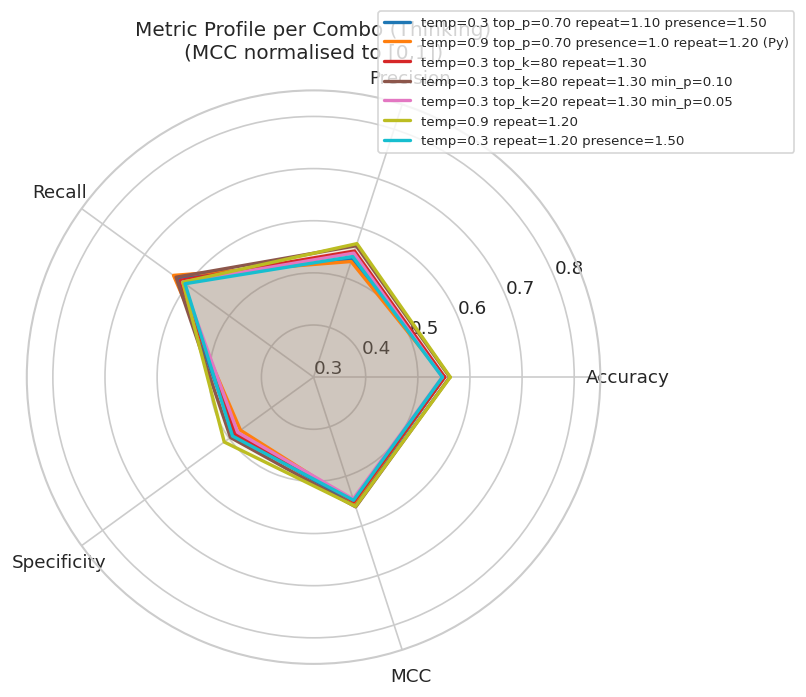

In [175]:
## Radar chart: each combo plotted across 5 metrics (avg across datasets)
## Metrics: accuracy, precision, recall, specificity, MCC (normalised to 0-1)

METRICS = ['accuracy', 'precision', 'recall', 'specificity', 'MCC']
METRIC_LABELS = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'MCC']

for df_mode, title_suffix in [(df_nt, 'Non-Thinking'), (df_t, 'Thinking')]:
    if df_mode.empty:
        continue

    combos = list(COMBO_META.keys())
    avg = df_mode.groupby('combo_suffix')[METRICS].mean().reindex(combos)

    # Normalise MCC from [-1,1] to [0,1]
    avg['MCC'] = (avg['MCC'] + 1) / 2

    N    = len(METRICS)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    cmap    = plt.cm.get_cmap('tab10', len(combos))

    for idx, combo in enumerate(combos):
        if combo not in avg.index:
            continue
        values = avg.loc[combo, METRICS].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=COMBO_META[combo]['label'].replace('\n', ' '), color=cmap(idx))
        ax.fill(angles, values, alpha=0.08, color=cmap(idx))

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(METRIC_LABELS, fontsize=11)
    ax.set_ylim(0.3, 0.85)
    ax.set_title(f'Metric Profile per Combo ({title_suffix})\n(MCC normalised to [0,1])', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    plt.show()

## Delta from Baseline — Per-Config Impact

/tmp/ipykernel_838864/3958414275.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _COMBO_CMAP = plt.cm.get_cmap('tab10', len(COMBO_META))


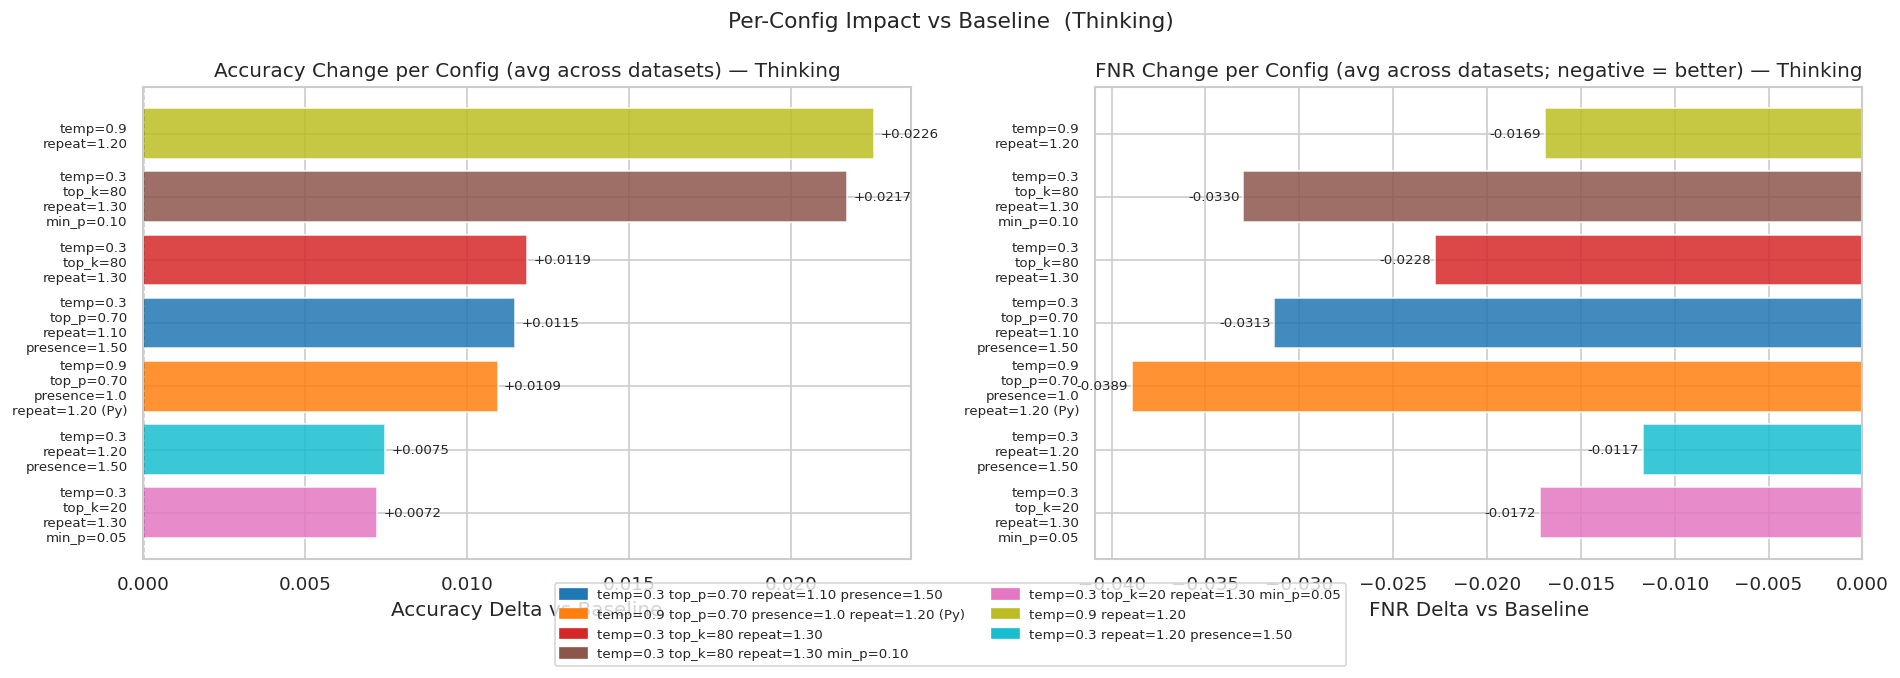

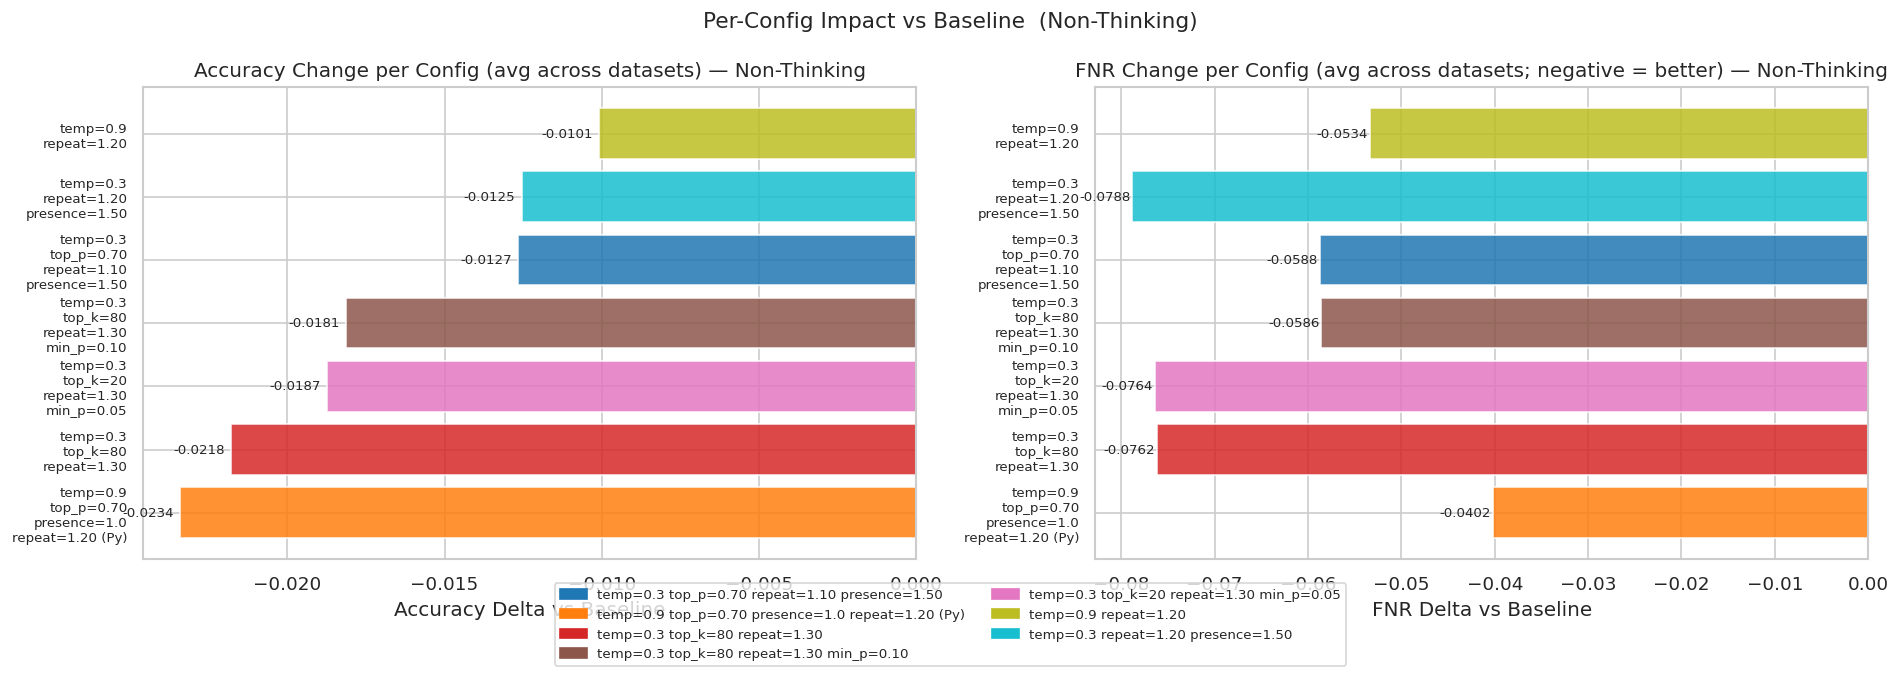

In [176]:
## Per-Config Impact vs Baseline — horizontal bar chart (Accuracy Δ and FNR Δ)
## Averaged across all datasets available for each combo.
## Shown separately for Thinking and Non-Thinking modes.

_COMBO_CMAP = plt.cm.get_cmap('tab10', len(COMBO_META))
COMBO_COLOR_MAP = {suffix: _COMBO_CMAP(i) for i, suffix in enumerate(COMBO_META.keys())}

for df_mode, title_suffix in [(df_t, 'Thinking'), (df_nt, 'Non-Thinking')]:
    if df_mode.empty:
        continue

    # Per-dataset baselines for this mode
    bl = (
        df_mode[df_mode['combo_suffix'] == 'baseline']
        [['dataset', 'accuracy', 'FNR', 'balanced_accuracy', 'MCC']]
        .rename(columns={'accuracy': 'bl_acc', 'FNR': 'bl_fnr',
                         'balanced_accuracy': 'bl_bacc', 'MCC': 'bl_mcc'})
    )
    if bl.empty:
        print(f'No baseline found for {title_suffix}, skipping.')
        continue

    non_bl = df_mode[df_mode['combo_suffix'] != 'baseline'].merge(bl, on='dataset', how='left')
    non_bl = non_bl.copy()
    non_bl['delta_acc']  = non_bl['accuracy']          - non_bl['bl_acc']
    non_bl['delta_fnr']  = non_bl['FNR']               - non_bl['bl_fnr']
    non_bl['delta_bacc'] = non_bl['balanced_accuracy'] - non_bl['bl_bacc']
    non_bl['delta_mcc']  = non_bl['MCC']               - non_bl['bl_mcc']

    avg_delta = (
        non_bl.groupby('combo_suffix')[['delta_acc', 'delta_fnr', 'delta_bacc', 'delta_mcc']]
        .mean()
        .reset_index()
    )
    avg_delta['combo_label'] = avg_delta['combo_suffix'].map(
        lambda s: COMBO_META.get(s, {}).get('label', s)
    )
    avg_delta = avg_delta.sort_values('delta_acc', ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(avg_delta) * 0.55 + 1.5)))

    for ax, (col, xlabel, title) in zip(axes, [
        ('delta_acc', 'Accuracy Delta vs Baseline',
         f'Accuracy Change per Config (avg across datasets) — {title_suffix}'),
        ('delta_fnr', 'FNR Delta vs Baseline',
         f'FNR Change per Config (avg across datasets; negative = better) — {title_suffix}'),
    ]):
        colors = [COMBO_COLOR_MAP.get(s, '#aaa') for s in avg_delta['combo_suffix']]
        ax.barh(avg_delta['combo_label'], avg_delta[col], color=colors, alpha=0.85)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.tick_params(axis='y', labelsize=8)
        for i, (_, row) in enumerate(avg_delta.iterrows()):
            v = row[col]
            ax.text(v + (2e-4 if v >= 0 else -2e-4), i,
                    f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

    # Legend by combo
    patches = [mpatches.Patch(color=COMBO_COLOR_MAP[s],
                               label=COMBO_META[s]['label'].replace('\n', ' '))
               for s in COMBO_META if s in avg_delta['combo_suffix'].values]
    fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=8,
               bbox_to_anchor=(0.5, -0.05))

    fig.suptitle(f'Per-Config Impact vs Baseline  ({title_suffix})', fontsize=13)
    fig.tight_layout()
    plt.show()


/tmp/ipykernel_838864/997296729.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _COMBO_CMAP = plt.cm.get_cmap('tab10', len(COMBO_META))


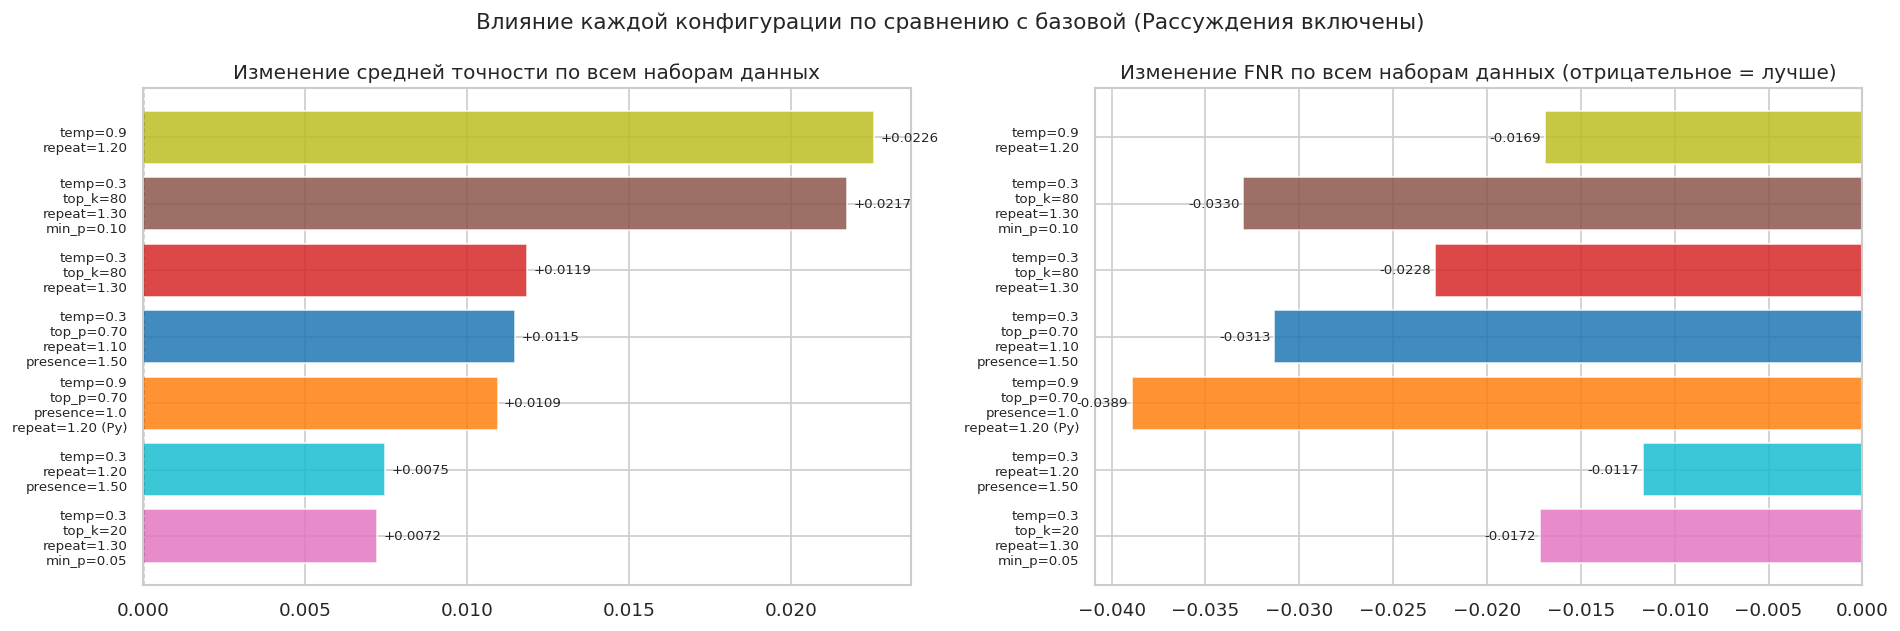

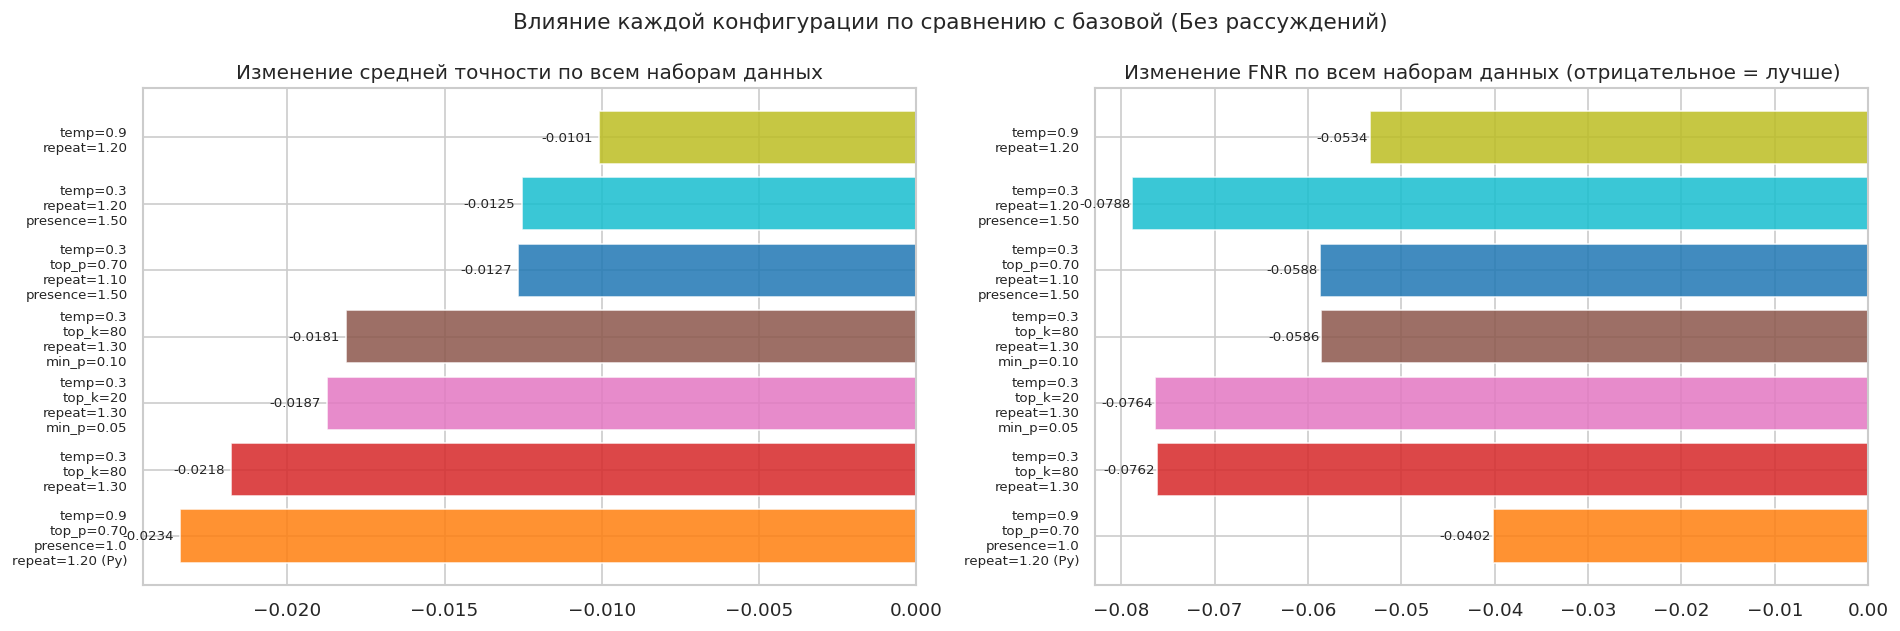

In [186]:
## Per-Config Impact vs Baseline — horizontal bar chart (Accuracy Δ and FNR Δ)
## Averaged across all datasets available for each combo.
## Shown separately for Thinking and Non-Thinking modes.

_COMBO_CMAP = plt.cm.get_cmap('tab10', len(COMBO_META))
COMBO_COLOR_MAP = {suffix: _COMBO_CMAP(i) for i, suffix in enumerate(COMBO_META.keys())}

for df_mode, title_suffix in [(df_t, 'Рассуждения включены'), (df_nt, 'Без рассуждений')]:
    if df_mode.empty:
        continue

    # Per-dataset baselines for this mode
    bl = (
        df_mode[df_mode['combo_suffix'] == 'baseline']
        [['dataset', 'accuracy', 'FNR', 'balanced_accuracy', 'MCC']]
        .rename(columns={'accuracy': 'bl_acc', 'FNR': 'bl_fnr',
                         'balanced_accuracy': 'bl_bacc', 'MCC': 'bl_mcc'})
    )
    if bl.empty:
        print(f'No baseline found for {title_suffix}, skipping.')
        continue

    non_bl = df_mode[df_mode['combo_suffix'] != 'baseline'].merge(bl, on='dataset', how='left')
    non_bl = non_bl.copy()
    non_bl['delta_acc']  = non_bl['accuracy']          - non_bl['bl_acc']
    non_bl['delta_fnr']  = non_bl['FNR']               - non_bl['bl_fnr']
    non_bl['delta_bacc'] = non_bl['balanced_accuracy'] - non_bl['bl_bacc']
    non_bl['delta_mcc']  = non_bl['MCC']               - non_bl['bl_mcc']

    avg_delta = (
        non_bl.groupby('combo_suffix')[['delta_acc', 'delta_fnr', 'delta_bacc', 'delta_mcc']]
        .mean()
        .reset_index()
    )
    avg_delta['combo_label'] = avg_delta['combo_suffix'].map(
        lambda s: COMBO_META.get(s, {}).get('label', s)
    )
    avg_delta = avg_delta.sort_values('delta_acc', ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(avg_delta) * 0.55 + 1.5)))

    for ax, (col, xlabel, title) in zip(axes, [
        ('delta_acc', 'Изменение средней точности по всем наборам данных',
         f'Изменение средней точности по всем наборам данных'),
        ('delta_fnr', 'Изменение FNR по всем наборам данных (отрицательное = лучше)',
         f'Изменение FNR по всем наборам данных (отрицательное = лучше)'),
    ]):
        colors = [COMBO_COLOR_MAP.get(s, '#aaa') for s in avg_delta['combo_suffix']]
        ax.barh(avg_delta['combo_label'], avg_delta[col], color=colors, alpha=0.85)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        # ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.tick_params(axis='y', labelsize=8)
        for i, (_, row) in enumerate(avg_delta.iterrows()):
            v = row[col]
            ax.text(v + (2e-4 if v >= 0 else -2e-4), i,
                    f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

    # Legend by combo
    patches = [mpatches.Patch(color=COMBO_COLOR_MAP[s],
                               label=COMBO_META[s]['label'].replace('\n', ' '))
               for s in COMBO_META if s in avg_delta['combo_suffix'].values]
    # fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=8,
    #            bbox_to_anchor=(0.5, -0.15))

    fig.suptitle(f'Влияние каждой конфигурации по сравнению с базовой ({title_suffix})', fontsize=13)
    fig.tight_layout()
    plt.show()
